
**Objective:**
Recommend suitable crops by identifying farms with similar conditions.


In [ ]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.svm import SVC

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ML-soil_weather_crop_dataset.csv to ML-soil_weather_crop_dataset.csv


In [ ]:
#Read exel file
df = pd.read_csv('ML-soil_weather_crop_dataset.csv')
# Display first  rows
df.head()

,Farm_ID,State,District,Soil_Type,Nitrogen,Phosphorus,Potassium,Soil_pH,Temperature,Humidity,Rainfall,Weather_Condition,Farm_Area_Acres,Irrigation_Type,Fertilizer_Used,Sowing_Month,Season,Recommended_Crop,Expected_Yield_Tons,Harvest_Duration_Days
0,1,Bihar,Ludhiana,Alluvial Soil,109.14,54.42,66.34,7.75,32.0,73.0,97.6,Humid,10.31,Tube Well,DAP,November,Zaid,Cotton,10.83,99
1,2,Rajasthan,Aurangabad,Laterite Soil,14.64,56.10,59.52,7.78,23.3,63.8,66.9,Moderate,14.54,Drip,Compost,July,Kharif,Millets,5.32,111
2,3,Rajasthan,Bhopal,Laterite Soil,58.82,74.68,96.91,8.61,33.5,66.1,238.6,Dry,40.59,Sprinkler,Compost,July,Kharif,Cotton,12.00,86
3,4,Punjab,Patiala,Alluvial Soil,20.88,27.61,47.57,6.92,31.1,63.3,132.9,Rainy,46.20,Canal,Urea,October,Zaid,Millets,6.15,101
4,5,Gujarat,Patiala,Alluvial Soil,NaN,49.94,41.05,7.66,22.0,41.1,153.9,Dry,24.89,Sprinkler,Urea,January,Rabi,Barley,9.04,117


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Farm_ID                50500 non-null  int64  
 1   State                  50500 non-null  object 
 2   District               50500 non-null  object 
 3   Soil_Type              50500 non-null  object 
 4   Nitrogen               49287 non-null  float64
 5   Phosphorus             49289 non-null  float64
 6   Potassium              49281 non-null  float64
 7   Soil_pH                50500 non-null  float64
 8   Temperature            49285 non-null  float64
 9   Humidity               49283 non-null  float64
 10  Rainfall               49285 non-null  float64
 11  Weather_Condition      50500 non-null  object 
 12  Farm_Area_Acres        50500 non-null  float64
 13  Irrigation_Type        50500 non-null  object 
 14  Fertilizer_Used        50500 non-null  object 
 15  So

In [ ]:
print("Rows And Columns:", df.shape)

Rows And Columns: (50500, 20)


In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Soil_Type,0
Nitrogen,1213
Phosphorus,1211
Potassium,1219
Soil_pH,0
Temperature,1215
Humidity,1217


In [ ]:
df.duplicated().any()

np.True_

In [ ]:
df.duplicated().sum()

np.int64(490)

In [ ]:
df[df.duplicated()]

,Farm_ID,State,District,Soil_Type,Nitrogen,Phosphorus,Potassium,Soil_pH,Temperature,Humidity,Rainfall,Weather_Condition,Farm_Area_Acres,Irrigation_Type,Fertilizer_Used,Sowing_Month,Season,Recommended_Crop,Expected_Yield_Tons,Harvest_Duration_Days
50000,13161,Tamil Nadu,Aurangabad,Sandy Soil,109.62,25.04,NaN,6.04,33.4,81.3,89.8,Dry,24.10,Tube Well,NPK,August,Kharif,Cotton,9.45,175
50001,37462,Tamil Nadu,Patiala,Alluvial Soil,60.44,17.80,50.38,7.73,NaN,18.4,45.2,Humid,25.87,Sprinkler,DAP,August,Rabi,Millets,5.42,120
50002,14120,Maharashtra,Kanpur,Laterite Soil,55.31,58.83,65.76,7.35,26.5,58.1,109.9,Humid,49.93,Drip,DAP,November,Rabi,Soybean,8.94,158
50003,6391,Maharashtra,Jaipur,Alluvial Soil,92.39,39.12,70.60,5.01,26.1,80.1,24.0,Dry,8.00,Canal,Organic Mix,October,Kharif,Millets,6.79,146
50004,9597,Gujarat,Nashik,Black Soil,43.05,30.24,12.08,8.84,25.9,58.5,214.2,Moderate,28.49,Tube Well,Compost,November,Zaid,Barley,6.17,165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50494,3638,Odisha,Jaipur,Sandy Soil,43.25,28.99,27.22,7.36,36.1,28.0,91.3,Cloudy,6.09,Canal,DAP,November,Zaid,Barley,5.60,84
50496,35187,Punjab,Patiala,Clay Soil,73.01,36.73,16.59,5.74,25.8,72.6,229.7,Dry,40.42,Tube Well,NPK,July,Zaid,Rice,8.95,94
50497,14980,Odisha,Aurangabad,Clay Soil,58.45,48.96,NaN,6.29,30.6,76.3,192.8,Cloudy,2.60,Canal,Potash,January,Rabi,Wheat,8.83,160
50498,20639,Rajasthan,Nashik,Laterite Soil,58.67,55.02,53.23,6.57,14.4,41.3,135.8,Cloudy,39.50,Tube Well,Compost,August,Kharif,Wheat,9.02,109


In [ ]:
data1 = df.drop_duplicates()

In [ ]:
data1.shape

(50010, 20)

In [ ]:

#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and Find out null value percentage
df['% null records'] = (df['null_records']/50010*100)
df

,column,null_records,% null records
0,Farm_ID,0,0.000000
1,State,0,0.000000
2,District,0,0.000000
3,Soil_Type,0,0.000000
4,Nitrogen,1201,2.401520
5,Phosphorus,1200,2.399520
6,Potassium,1200,2.399520
7,Soil_pH,0,0.000000
8,Temperature,1198,2.395521
9,Humidity,1201,2.401520


In [ ]:
 data1.columns.str.strip()


Index(['Farm_ID', 'State', 'District', 'Soil_Type', 'Nitrogen', 'Phosphorus',
       'Potassium', 'Soil_pH', 'Temperature', 'Humidity', 'Rainfall',
       'Weather_Condition', 'Farm_Area_Acres', 'Irrigation_Type',
       'Fertilizer_Used', 'Sowing_Month', 'Season', 'Recommended_Crop',
       'Expected_Yield_Tons', 'Harvest_Duration_Days'],
      dtype='object')

In [ ]:
print(data1.columns)

Index(['Farm_ID', 'State', 'District', 'Soil_Type', 'Nitrogen', 'Phosphorus',
       'Potassium', 'Soil_pH', 'Temperature', 'Humidity', 'Rainfall',
       'Weather_Condition', 'Farm_Area_Acres', 'Irrigation_Type',
       'Fertilizer_Used', 'Sowing_Month', 'Season', 'Recommended_Crop',
       'Expected_Yield_Tons', 'Harvest_Duration_Days'],
      dtype='object')


In [ ]:
Nitrogen_mean = data1['Nitrogen'].mean()
Nitrogen_mean
data1['Nitrogen'] = data1['Nitrogen'].fillna(Nitrogen_mean)

Phosphorus_mean = data1['Phosphorus'].mean()
Phosphorus_mean
data1['Phosphorus'] = data1['Phosphorus'].fillna(Phosphorus_mean)

Potassium_mean = data1['Potassium'].mean()
Potassium_mean
data1['Potassium'] = data1['Potassium'].fillna(Potassium_mean)

Temperature_mean = data1['Temperature'].mean()
Temperature_mean
data1['Temperature'] = data1['Temperature'].fillna(Temperature_mean)

Humidity_mean = data1['Humidity'].mean()
Humidity_mean
data1['Humidity'] = data1['Humidity'].fillna(Humidity_mean)

Rainfall_mean = data1['Rainfall'].mean()
Rainfall_mean
data1['Rainfall'] = data1['Rainfall'].fillna(Rainfall_mean)

Recommended_Crop_mode = data1['Recommended_Crop'].mode()[0]
data1['Recommended_Crop'] = data1['Recommended_Crop'].fillna(Recommended_Crop_mode)

In [ ]:
data1.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Soil_Type,0
Nitrogen,0
Phosphorus,0
Potassium,0
Soil_pH,0
Temperature,0
Humidity,0


In [ ]:
print(data1.columns)

Index(['Farm_ID', 'State', 'District', 'Soil_Type', 'Nitrogen', 'Phosphorus',
       'Potassium', 'Soil_pH', 'Temperature', 'Humidity', 'Rainfall',
       'Weather_Condition', 'Farm_Area_Acres', 'Irrigation_Type',
       'Fertilizer_Used', 'Sowing_Month', 'Season', 'Recommended_Crop',
       'Expected_Yield_Tons', 'Harvest_Duration_Days'],
      dtype='object')


In [ ]:
data1['State'].value_counts()

,count
State,
Madhya Pradesh,5166
Tamil Nadu,5070
Uttar Pradesh,5019
Karnataka,5000
Odisha,4989
Punjab,4978
Gujarat,4977
Maharashtra,4969
Bihar,4937


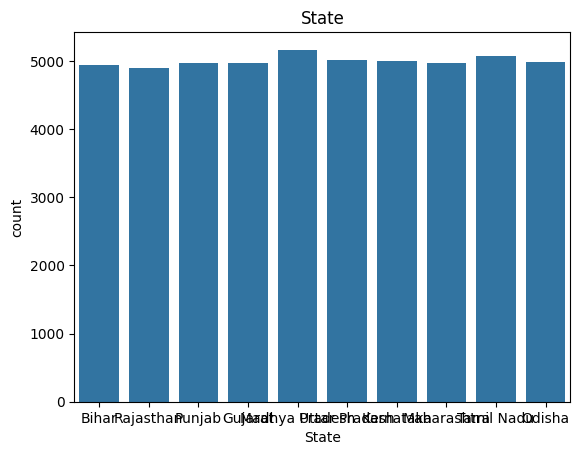

In [ ]:
sns.countplot(x='State', data=data1)
plt.title('State')
plt.show()

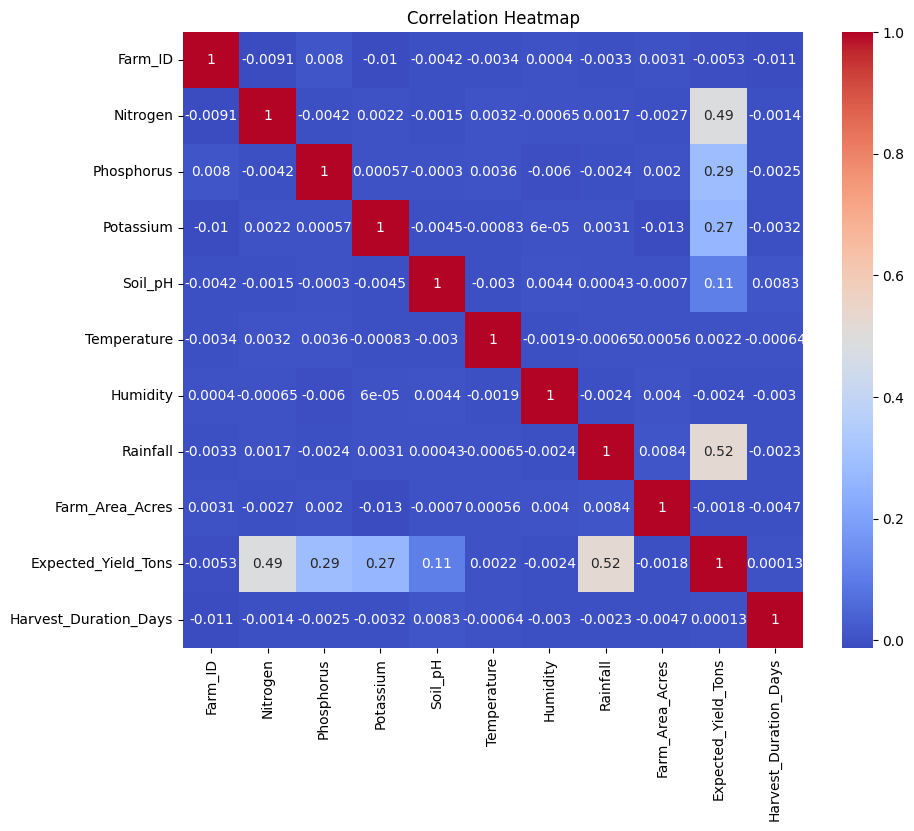

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(data1.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
sns.pairplot(data1, hue='Temperature')
plt.show()

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
Categorical_col = data1.select_dtypes(include = 'object').columns
Categorical_col

Index([], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data1['State'] = le.fit_transform(data1['State'])
data1['District'] = le.fit_transform(data1['District'])
data1['Soil_Type'] = le.fit_transform(data1['Soil_Type'])
data1['Weather_Condition'] = le.fit_transform(data1['Weather_Condition'])
data1['Irrigation_Type'] = le.fit_transform(data1['Irrigation_Type'])
data1['Fertilizer_Used'] = le.fit_transform(data1['Fertilizer_Used'])
data1['Sowing_Month'] = le.fit_transform(data1['Sowing_Month'])
data1['Season'] = le.fit_transform(data1['Season'])
data1['Recommended_Crop'] = le.fit_transform(data1['Recommended_Crop'])
data1['Rainfall'] = le.fit_transform(data1['Rainfall'])
data1['Humidity'] = le.fit_transform(data1['Humidity'])
data1['Temperature'] = le.fit_transform(data1['Temperature'])
data1['Soil_Type'] = le.fit_transform(data1['Soil_Type'])

In [ ]:
X = data1[['Temperature',
        'Humidity',
        'Rainfall',
        'Season',
        'Soil_Type']]
y = data1['Recommended_Crop']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test)
print(y_pred)

[0 6 2 ... 1 1 6]


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[  92  169   54   43   50   20   50   20    9   39]
 [ 184  598   93   73  275   57  136   18   17  110]
 [  86  150   44   40   43   21   55    6    7   41]
 [  90  154   57   37   53   20   70    5   10   41]
 [ 124  345   79   62 1589   31   53   11    6  182]
 [ 103  136   55   45   59   21   55   10    8   46]
 [ 206  379  140   90  106   58  244   21   18   81]
 [  97  169   59   43   54   21   54   12    4   34]
 [  98  151   64   53   50   33   60   13   12   33]
 [ 174  316  124   92  221   48  121   21   11  260]]


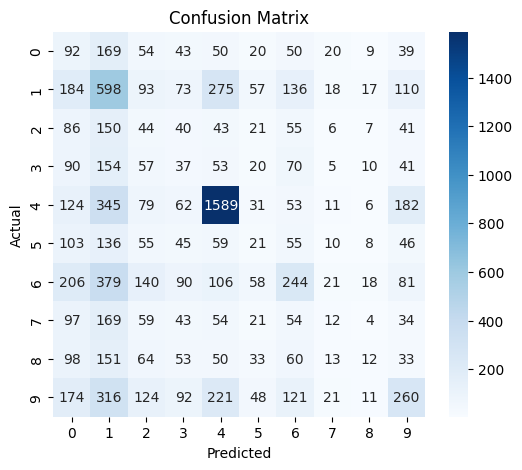

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.07      0.17      0.10       546
           1       0.23      0.38      0.29      1561
           2       0.06      0.09      0.07       493
           3       0.06      0.07      0.07       537
           4       0.64      0.64      0.64      2482
           5       0.06      0.04      0.05       538
           6       0.27      0.18      0.22      1343
           7       0.09      0.02      0.04       547
           8       0.12      0.02      0.04       567
           9       0.30      0.19      0.23      1388

    accuracy                           0.29     10002
   macro avg       0.19      0.18      0.17     10002
weighted avg       0.30      0.29      0.28     10002



In [ ]:
accuracy_scores = []

for i in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X_train, y_train)

    pred_i = model.predict(X_test)

    score = accuracy_score(y_test, pred_i)

    accuracy_scores.append(score)

print(accuracy_scores)

[0.27714457108578283, 0.27224555088982205, 0.2908418316336733, 0.3046390721855629, 0.3156368726254749, 0.3228354329134173, 0.32893421315736854, 0.33293341331733656, 0.33763247350529896, 0.3421315736852629, 0.3426314737052589, 0.34643071385722857, 0.34753049390121976, 0.35242951409718054, 0.35452909418116374, 0.3567286542691462, 0.3582283543291342, 0.3615276944611078, 0.36162767446510696, 0.3644271145770846]


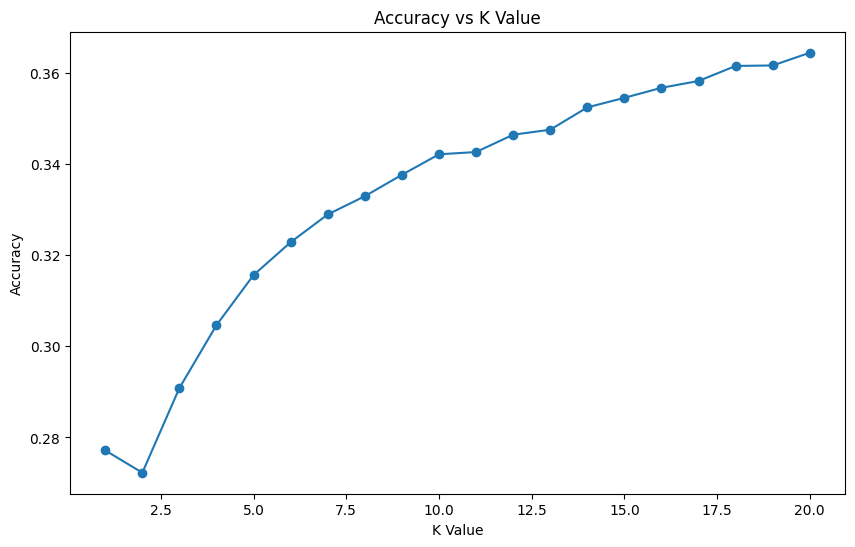

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracy_scores, marker='o', linestyle='-')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value')

plt.show()

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=11)
final_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [ ]:
final_pred = final_model.predict(X_test)
print(final_pred)

[6 9 2 ... 3 1 6]


In [ ]:
final_accuracy = accuracy_score(y_test, final_pred)
print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.3426314737052589


**Conclusion:**

This project successfully developed a Crop Recommendation System using the KNN algorithm.
The dataset was analyzed and preprocessed to improve data quality and model performance.
Exploratory Data Analysis helped identify patterns and relationships among the features.
Feature scaling was applied because KNN is a distance-based algorithm.
The model was trained using soil and weather-related parameters to predict suitable crops.
Different values of K were tested to find the optimal model performance.
The KNN model achieved an accuracy of approximately 34.26%.
The results show that machine learning can assist farmers in making crop selection decisions.
This system can help improve agricultural productivity and resource utilization